## Looking at *Home Sapiens* model the # of AMTL (num_amtl) as a fraction of sockets stratified by **age**. Age is measured with error and the standard deviation is given in **std_age**. Use this to consider measurement error in the model <br>
### Numpyro version
By Prabhakar Srivastava

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import vmap
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
from jax.random import PRNGKey, split
from graphviz import Digraph as gr
import arviz as az
import operator

Plotting Style and random seed

In [2]:
random_seed = sum(map(ord, "Homework 7 Numpyro Measurement Error"))

plt.style.use("statistical-rethinking-2023.mplstyle")

numpyro.set_host_device_count(4)
numpyro.enable_x64()

DAG for process <br>
We observe only age* and not the true age

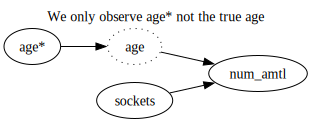

In [3]:
g = gr(graph_attr={"rankdir": "LR", "label":"We only observe age* not the true age", "labelloc":"t"})
g.node("age*")
g.node("age", style="dotted")
g.node("num_amtl")
g.node("sockets")
g.edge(tail_name="age*", head_name="age")
g.edge(tail_name="age", head_name="num_amtl")
g.edge(tail_name="sockets", head_name="num_amtl")
g

Import the data

In [4]:
filepath_str:str = "https://raw.githubusercontent.com/rmcelreath/stat_rethinking_2026/main/homework/amtl_homo_aggregated.csv"

df = pd.read_csv(filepath_str)
pd.concat([df.head(), df.tail()])

,specimen,age,stdev_age,num_amtl,sockets
0,NMNH227455,11.661009,1.268039,0,32
1,MH1503,15.567015,1.807743,1,32
2,MH4767,15.567015,1.807743,2,32
3,NMNH380448,15.784015,1.839889,0,32
4,UVS46,16.902650,1.892974,0,32
305,NMNH225029,47.011596,21.358443,0,16
306,MH12326,50.164872,22.998910,6,16
307,MH12319,51.741511,23.819206,0,16
308,MH12322,59.624702,27.921159,1,16
309,MH12321,71.224255,31.416954,0,16


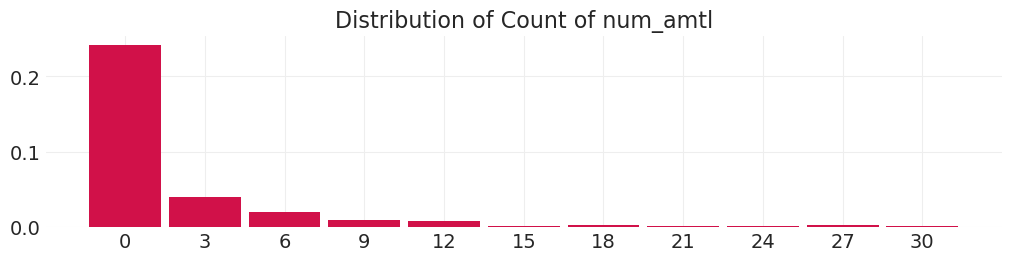

In [5]:
fig, ax = plt.subplots(figsize=(10., 2.5))
az.plot_dist(df["num_amtl"].values,
             ax=ax,
            )
ax.set_title("Distribution of Count of num_amtl")
plt.show()

Distribution of age

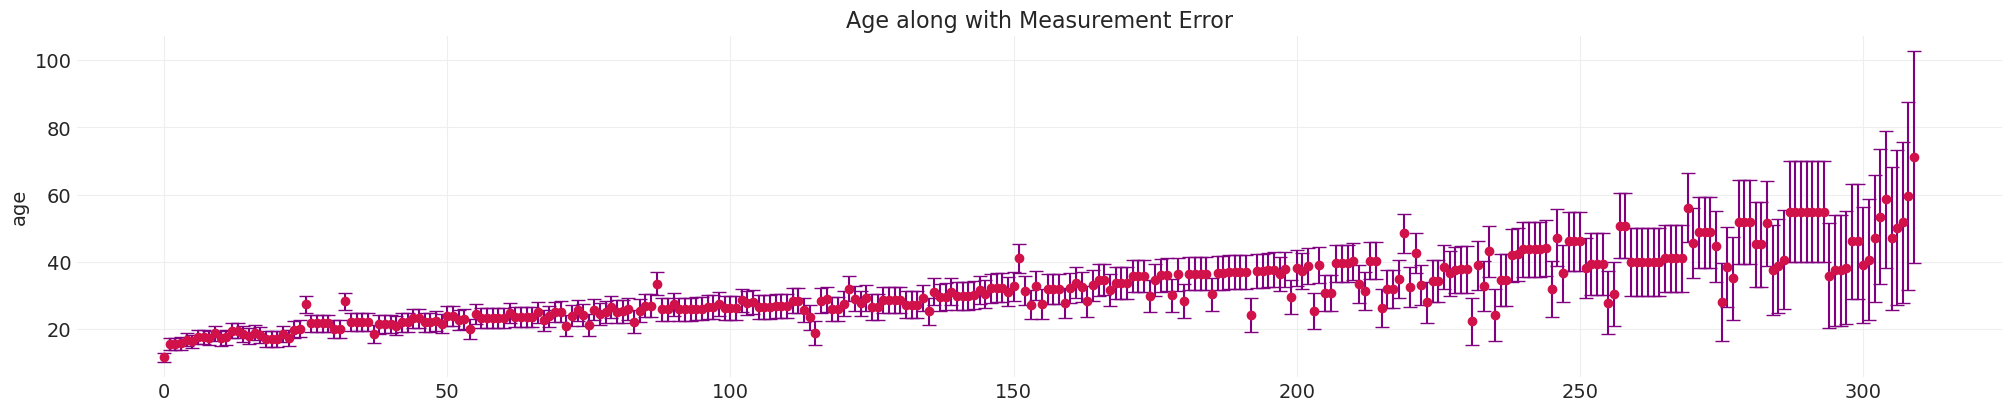

In [6]:
fig, ax = plt.subplots(figsize=(20., 4.))
age_lower, age_upper = [op(df["age"].values, df["stdev_age"].values) for op in (operator.sub, operator.add)]

ax.errorbar(
    range(len(df)),
    df["age"].values,
    yerr=df["stdev_age"].values,
    fmt="o",
    ecolor="purple",
    capsize=5
)

ax.set_ylabel("age")
ax.set_title("Age along with Measurement Error")
plt.show()

In [7]:
a_data = jnp.array(df["age"].values)
a_std = jnp.array(df["stdev_age"].values)
s_data = jnp.array(df["sockets"].values)
amtl_data = jnp.array(df["num_amtl"].values)

Model 1: No Measurment Error into account

In [8]:
def hm_07_no_error(s_data:jnp.array = s_data, 
                   a_data:jnp.array = a_data,
                   amtl_data:jnp.array = amtl_data
                  ) -> None:
    '''
    Model 1: Not taking into account measure error of age
    '''

    # Priors
    α = numpyro.sample("α", dist.Normal(loc=0., scale=1.))
    β_s = numpyro.sample("β_s", dist.Normal(loc=0., scale=1.))
    β_a = numpyro.sample("β_a", dist.Normal(loc=0., scale=1.))

    # Regression
    λ = α + β_s * s_data + β_a * a_data

    Nobs = len(s_data)

    with numpyro.plate("obs", Nobs):
        amtl = numpyro.sample("amtl", dist.Poisson(jnp.exp(λ)), obs=amtl_data)

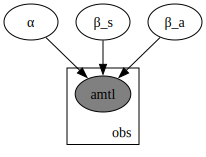

In [9]:
numpyro.render_model(hm_07_no_error)

In [10]:
rng_key = PRNGKey(random_seed)
rng_key, rng_subkey = split(rng_key)
mcmc_no_error = MCMC(NUTS(hm_07_no_error), num_samples=1_000, num_warmup=1_000, num_chains=4)
mcmc_no_error.run(rng_subkey)

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

In [11]:
mcmc_no_error.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         α     -2.49      0.22     -2.49     -2.82     -2.11   1026.73      1.00
       β_a      0.06      0.00      0.06      0.06      0.07   1397.40      1.00
       β_s      0.05      0.01      0.05      0.04      0.06   1159.90      1.00

Number of divergences: 0


Let us obtain the samples now for no errors

In [12]:
samples_no_error = mcmc_no_error.get_samples()

Let us now obtain the mean number of amtl this is given by $\lambda$

In [13]:
α = samples_no_error["α"]
β_a = samples_no_error["β_a"]
β_s = samples_no_error["β_s"]
λ_no_error = vmap(lambda a, ba, bs: jnp.exp(a + ba * a_data + bs * s_data), in_axes=(0, 0, 0))(α, β_a, β_s)

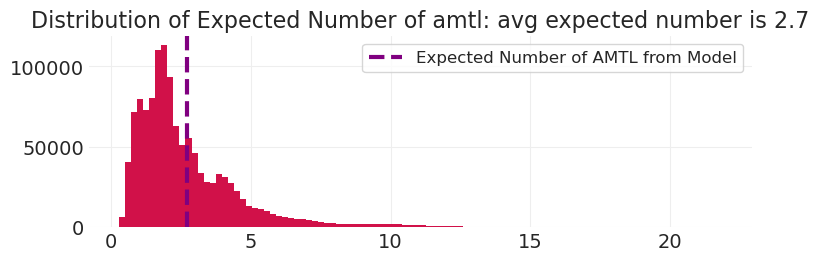

In [14]:
_, ax = plt.subplots(figsize=(7.5, 2.5))
ax.hist(λ_no_error.reshape(-1, 1), bins=100)
ax.set_title("Distribution of Expected Number of amtl: avg expected number is {}".format(df["num_amtl"].mean().round(2)))
ax.axvline(λ_no_error.mean(), color="purple", lw=3, ls="--", label="Expected Number of AMTL from Model")
#ax.axvline(df["num_amtl"].mean(), color="red", lw=3, ls="--", label="Avg Number of AMTL from Data")
ax.legend()
plt.show()

Model 2: Accounting for Measurement Error of age given by stdev_age: We now assume we have observed age* but not the true age which we model with using the stdev_age

In [15]:
def hm_07_w_error(s_data:jnp.array = s_data,
                  a_star:jnp.array = a_data,
                  a_std:jnp.array = a_std,
                  amtl_data:jnp.array = amtl_data) -> None:
    '''
    Model 2: Taking into account measurement error in age through the measured standard deviation
    We assume now that we observe a_star for age and not the true age which we now model
    '''

    # Priors
    α = numpyro.sample("α", dist.Normal(loc=0., scale=2.0)) # Intercept
    β_s = numpyro.sample("β_s", dist.Normal(loc=0., scale=1.0)) # Coefficient for socket
    β_a = numpyro.sample("β_a", dist.Normal(loc=0., scale=1.0)) # Coefficient for age

    # Model "True" age using observed age and the associated standard deviation
    Nobs = len(s_data)
    with numpyro.plate("obs", Nobs):
        # Age is modeled as a truncated normal with mean of observed age and scale of stdev_age
        # We truncate it with a lower value of 0 and a high of 100 as this seems reasonable
        age = numpyro.sample("age", dist.TruncatedNormal(loc=a_star, scale=a_std, low=0., high=100.))


    # Regression part
    λ = α + β_s * s_data + β_a * age # Same as before except we use the true age

    # likelihood
    amtl = numpyro.sample("amtl", dist.Poisson(jnp.exp(λ)), obs=amtl_data)

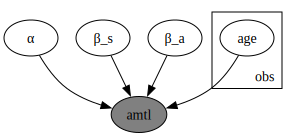

In [16]:
numpyro.render_model(hm_07_w_error)

Sampling the new model

In [17]:
mcmc_w_error = MCMC(NUTS(hm_07_w_error), num_samples=1_000, num_warmup=1_000, num_chains=4)
mcmc_w_error.run(rng_key)

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

In [18]:
samples_w_error = mcmc_w_error.get_samples()

In [19]:
α_err = samples_w_error["α"]
β_s_err = samples_w_error["β_s"]
β_a_err = samples_w_error["β_a"]
age = samples_w_error["age"]
λ_w_error = vmap(lambda a0, bs, ba, a: jnp.exp(a0 + bs * s_data + ba * a), in_axes=(0, 0, 0, 0))(α_err, β_s_err, β_a_err, age)

Compare the two models

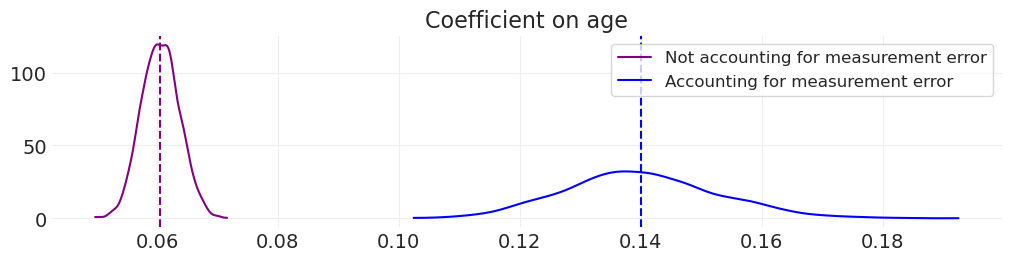

In [20]:
# Effect of age
_, ax = plt.subplots(figsize=(10., 2.5))
az.plot_dist(
    β_a,
    label="Not accounting for measurement error",
    color="purple",
    ax=ax
)
ax.axvline(β_a.mean(), color="purple", ls="--")
az.plot_dist(
    β_a_err,
    label="Accounting for measurement error",
    color="blue",
    ax=ax
)
ax.axvline(β_a_err.mean(), color="blue", ls="--")
ax.set_title("Coefficient on age")
plt.show()

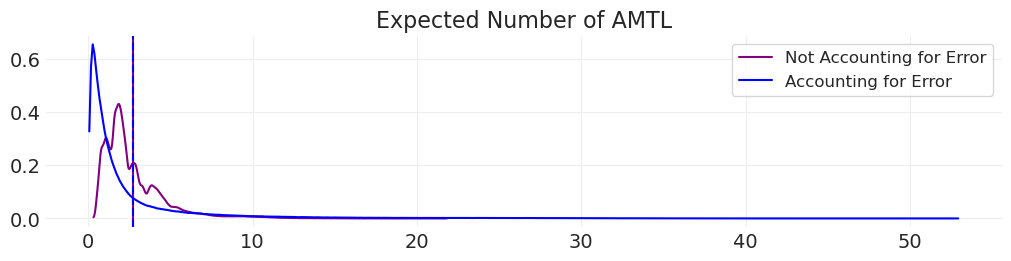

In [21]:
_, ax = plt.subplots(figsize=(10., 2.5))
az.plot_dist(
    λ_no_error,
    label="Not Accounting for Error",
    color="purple",
    ax=ax
)
ax.axvline(λ_no_error.mean(), color="purple")
az.plot_dist(
    λ_w_error,
    label="Accounting for Error",
    color="blue",
    ax=ax
)
ax.axvline(λ_w_error.mean(), color="blue", ls="--")
ax.set_title("Expected Number of AMTL")
plt.show()